# ⚡️ AdaBoost Regression

## 📖 What Is AdaBoost?

**AdaBoost (Adaptive Boosting)** is an ensemble method that combines multiple **weak learners** (typically shallow decision trees) by adaptively adjusting their weights based on how well they perform on the training data.

Unlike Gradient Boosting, which fits residuals using gradient descent, **AdaBoost adjusts the weights of the training data points**: harder-to-predict points receive more focus in the next iteration.

---

### 🔍 Key Ideas

- Weak learners are trained sequentially.
- After each round, examples with higher errors are given **more weight**.
- The final prediction is a **weighted sum** of all weak learners.

---

### Implementation
## ⚡️ AdaBoost Regression: Step-by-Step

Let’s denote:
- Training data: $ \{(x_i, y_i)\}_{i=1}^n $
- Number of boosting rounds: $ M $
- Base learner (e.g., decision tree): $ h_m(x) $
- Final model: $ F(x) = \sum_{m=1}^M \alpha_m h_m(x) $


### 🔁 Steps

1. **Initialize sample weights**  
   $$
   w_i = \frac{1}{n} \quad \text{for all } i = 1, \dots, n
   $$

2. **For** $ m = 1 $ to $ M $:  
   a. **Fit a base learner** $ h_m(x) $ to the training data using weights $ w_i $  
   
   b. Compute the error:  
   $$
   \varepsilon_m = \sum_{i=1}^n w_i \cdot |y_i - h_m(x_i)|
   $$
   
   c. Compute model weight:  
   $$
   \alpha_m = \log\left(\frac{1}{\varepsilon_m}\right)
   \quad \text{(or another weighting function)}
   $$
   
   d. **Update sample weights**:  
   $$
   w_i \leftarrow w_i \cdot \exp\left(\alpha_m \cdot |y_i - h_m(x_i)|\right)
   $$
   
   e. Normalize weights so that $ \sum w_i = 1 $

3. **Final model prediction**:  
   $$
   F(x) = \sum_{m=1}^M \alpha_m \cdot h_m(x)
   $$

---

### 🧠 Notes

- The form of $ \alpha_m $ and the weight update rule can vary depending on the variant and loss function.
- For **classification**, indicator functions and classification error are used instead of absolute error.




### ⚙️ Key Parameters (in `AdaBoostRegressor`)

| Parameter | Description |
|-----------|-------------|
| `n_estimators` | Number of boosting rounds |
| `learning_rate` | Shrinks contribution of each regressor |
| `base_estimator` | Typically a shallow `DecisionTreeRegressor` |

---

###  Practical tips
AdaBoost can be more sensitive to outliers (because it keeps emphasizing hard examples).

Gradient Boosting is usually more robust and performs better with proper regularization.

### 🧪 Simulated Example




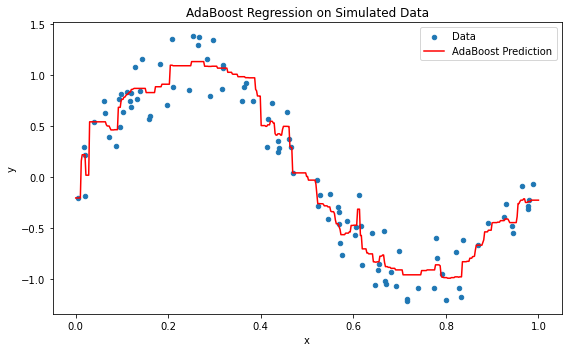

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

# Simulated data
np.random.seed(0)
X = np.sort(np.random.rand(100, 1), axis=0)
y = np.sin(2 * np.pi * X).ravel() + np.random.normal(0, 0.2, size=100)
X_plot = np.linspace(0, 1, 500).reshape(-1, 1)

# Fit AdaBoost
ada = AdaBoostRegressor(
    base_estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=100,
    learning_rate=0.5,
    random_state=0
)
ada.fit(X, y)

# Predict
y_pred = ada.predict(X_plot)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y, s=20, label="Data")
plt.plot(X_plot, y_pred, color="red", label="AdaBoost Prediction")
plt.title("AdaBoost Regression on Simulated Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

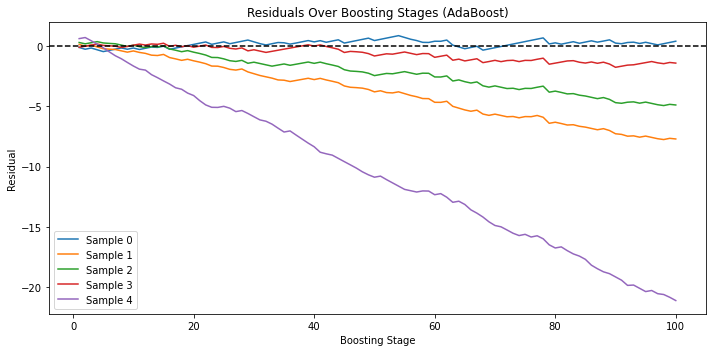

In [7]:
n_estimators = len(ada.estimators_)
residuals = []

# Stage-by-stage residuals
y_pred = np.zeros_like(y)
for m in range(n_estimators):
    pred_m = ada.learning_rate * ada.estimators_[m].predict(X)
    y_pred += pred_m
    residuals.append(y - y_pred)

# Convert to array: shape (n_stages, n_samples)
residuals = np.array(residuals)

# Plot evolution for a few sample points
plt.figure(figsize=(10, 5))
for i in range(5):  # select 5 sample points
    plt.plot(range(1, n_estimators + 1), residuals[:, i], label=f"Sample {i}")
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Boosting Stage")
plt.ylabel("Residual")
plt.title("Residuals Over Boosting Stages (AdaBoost)")
plt.legend()
plt.tight_layout()
plt.show()


## 🏠 Real Data: California Housing

R^2: 0.3779
MSE: 0.8161


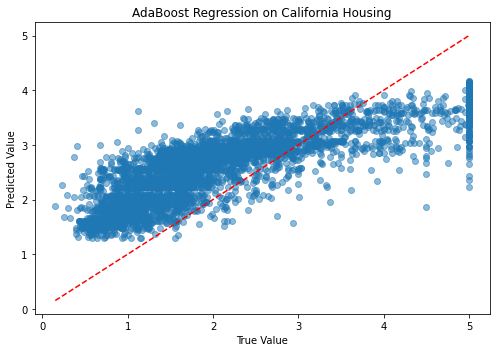

In [5]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

# Load data
data = fetch_california_housing()
X_real = data.data
y_real = data.target
feature_names = data.feature_names

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_real, y_real, test_size=0.2, random_state=1)

# Fit AdaBoost
ada_real = AdaBoostRegressor(
    base_estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=200,
    learning_rate=0.5,
    random_state=1
)
ada_real.fit(X_train, y_train)
y_pred_real = ada_real.predict(X_test)

# Evaluation
print(f"R^2: {r2_score(y_test, y_pred_real):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_real):.4f}")

# Plot predicted vs. true
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_real, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True Value")
plt.ylabel("Predicted Value")
plt.title("AdaBoost Regression on California Housing")
plt.tight_layout()
plt.show()

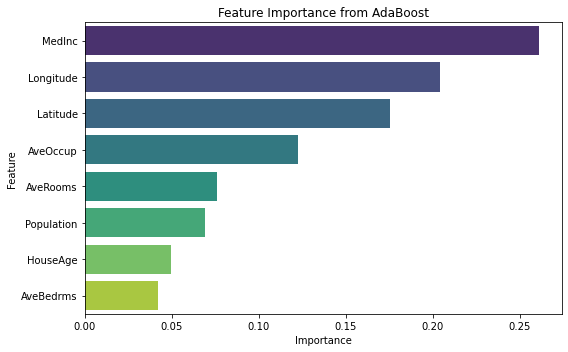

In [6]:
# Feature importance
importances = ada_real.feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance from AdaBoost")
plt.tight_layout()
plt.show()

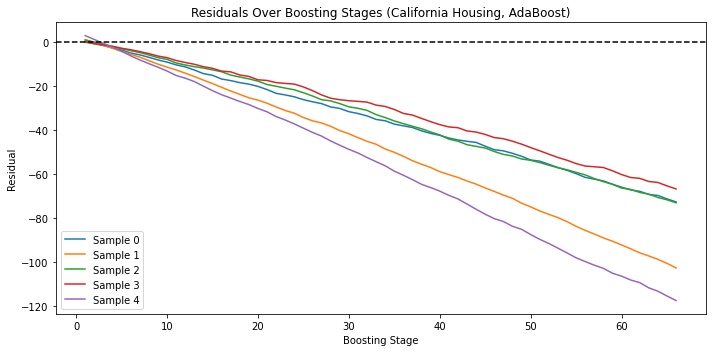

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

# Load and preprocess data
data = fetch_california_housing()
X = data.data
y = data.target

# Optional: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=0)

# Fit AdaBoost
ada = AdaBoostRegressor(
    base_estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=100,
    learning_rate=0.5,
    random_state=0
)
ada.fit(X_train, y_train)

# Track residuals over stages (on test set)
n_estimators = len(ada.estimators_)
y_pred = np.zeros_like(y_test)
residuals = []

for m in range(n_estimators):
    pred_m = ada.learning_rate * ada.estimators_[m].predict(X_test)
    y_pred += pred_m
    residuals.append(y_test - y_pred)

residuals = np.array(residuals)  # shape: (n_stages, n_samples)

# Plot residual evolution for a few test samples
plt.figure(figsize=(10, 5))
for i in range(5):  # show 5 randomly chosen test points
    plt.plot(range(1, n_estimators + 1), residuals[:, i], label=f"Sample {i}")
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Boosting Stage")
plt.ylabel("Residual")
plt.title("Residuals Over Boosting Stages (California Housing, AdaBoost)")
plt.legend()
plt.tight_layout()
plt.show()